# 2 - Interval Analysis

## Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g

In [91]:
df = g.load_labels()
df.head()

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,...,label,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,baseCase,volta
0,1,1,3/2,3/2,3.0,0.375,3/8,9/8,3,1,...,Ab(b5),NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,1.375,NaN,NaN
1,2,2,9/2,9/2,20.0,0.000,0,7/8,3,1,...,g5,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,2.000,NaN,NaN
2,7,7,49/2,49/2,3.0,0.375,3/8,9/8,3,1,...,Ab(b5),NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,7.375,NaN,NaN
3,8,8,55/2,55/2,20.0,0.000,0,7/8,3,1,...,g5,NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,8.000,NaN,NaN
4,13,13,95/2,95/2,3.0,0.375,3/8,9/8,3,1,...,Ab(b5),NaN,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,13.375,NaN,NaN


In [93]:
subset = df[(df['workTitle'] == 'Four') | (df['workTitle'] == 'Blues By Five')]
subset = subset[subset['artist'].isin(['John Coltrane', 'Miles Davis'])]
subset.head()

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,...,label,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,baseCase,volta
3360,1,1,0,0,4.0,0.0,0,4/4,1,1,...,Bb7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,1.0,NaN,NaN
3361,2,2,4,4,4.0,0.0,0,4/4,1,1,...,Eb7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,2.0,NaN,NaN
3362,3,3,8,8,4.0,0.0,0,4/4,1,1,...,Bb7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,3.0,NaN,NaN
3363,4,4,12,12,4.0,0.0,0,4/4,1,1,...,Bb7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,4.0,NaN,NaN
3364,5,5,16,16,4.0,0.0,0,4/4,1,1,...,Eb7,NaN,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),by_Carles_Margarit,1956,5.0,NaN,NaN


In [95]:
import re
def fix_flats(label):
    # Replace flats in the root (only at beginning or after slash)
    label = re.sub(r'([A-Ga-g])b', r'\1-', label)
    return label

def clean_chord_label(label):
    if not isinstance(label, str):
        return label
        
    label = re.sub(r'\((.*?)\)', r'\1', label)
    label = fix_flats(label)
    
    label = label.replace('Maj', 'maj')   # fix Maj7 → maj7
    label = label.strip()
    
    return label

from functools import lru_cache

@lru_cache(maxsize=None)
def parse_chord(label):
    return music21.harmony.ChordSymbol(label)

def get_ilset(label):
    try:
        chord = parse_chord(label)
        chord_pitches = chord.pitches
        chord_tones = [p.name for p in chord_pitches]
        return chord_tones
    except Exception as e:
        return np.nan

@lru_cache(maxsize=None)
def parse_chord(label):
    return music21.harmony.ChordSymbol(label)

from itertools import combinations
def get_intervals(label):
    try:
        chord = parse_chord(label)
        pcs = [p.pitchClass for p in chord.pitches]

        # Generate all unordered pitch class pairs
        intervals = []
        for pc1, pc2 in combinations(pcs, 2):
            interval = (pc2 - pc1) % 12
            intervals.append(interval)
        
        return intervals

    except Exception as e:
        return np.nan

pc_to_interval_name = {
    0: "P1",
    1: "m2",
    2: "M2",
    3: "m3",
    4: "M3",
    5: "P4",
    6: "A4/d5",   
    7: "P5",
    8: "m6",
    9: "M6",
    10: "m7",
    11: "M7"
}


In [97]:
df['label'] = df['label'].apply(clean_chord_label)

In [99]:
df['ILS'] = df['label'].apply(get_ilset)

In [101]:
df['interval'] = df['label'].apply(get_intervals)
df['intervalName'] = df['interval'].apply(
    lambda lst: [pc_to_interval_name[i] for i in lst] if isinstance(lst, list) else np.nan
)
df

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,...,workTitle,fnames,rel_paths,recording_year,time,baseCase,volta,ILS,interval,intervalName
0,1,1,3/2,3/2,3.0,0.375,3/8,9/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,1.375,NaN,NaN,"[A-, C, E--]","[4, 6, 2]","[M3, A4/d5, M2]"
1,2,2,9/2,9/2,20.0,0.000,0,7/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,2.000,NaN,NaN,"[G, D]",[7],[P5]
2,7,7,49/2,49/2,3.0,0.375,3/8,9/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,7.375,NaN,NaN,"[A-, C, E--]","[4, 6, 2]","[M3, A4/d5, M2]"
3,8,8,55/2,55/2,20.0,0.000,0,7/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,8.000,NaN,NaN,"[G, D]",[7],[P5]
4,13,13,95/2,95/2,3.0,0.375,3/8,9/8,3,1,...,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,13.375,NaN,NaN,"[A-, C, E--]","[4, 6, 2]","[M3, A4/d5, M2]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27555,217,217,864,864,4.0,0.000,0,4/4,6,1,...,The World Is Getting Smaller,The World is Getting Smaller - Snarky Puppy,by_seemajorsheetmusic,2007,217.000,NaN,NaN,"[G, B-, D, F]","[3, 7, 10, 4, 7, 3]","[m3, P5, m7, M3, P5, m3]"
27556,218,218,868,868,4.0,0.000,0,4/4,6,1,...,The World Is Getting Smaller,The World is Getting Smaller - Snarky Puppy,by_seemajorsheetmusic,2007,218.000,NaN,NaN,"[A, C#, E, G]","[4, 7, 10, 3, 6, 3]","[M3, P5, m7, m3, A4/d5, m3]"
27557,219,219,872,872,4.0,0.000,0,4/4,6,1,...,The World Is Getting Smaller,The World is Getting Smaller - Snarky Puppy,by_seemajorsheetmusic,2007,219.000,NaN,NaN,"[D, F, A]","[3, 7, 4]","[m3, P5, M3]"
27558,220,220,876,876,2.0,0.000,0,4/4,6,1,...,The World Is Getting Smaller,The World is Getting Smaller - Snarky Puppy,by_seemajorsheetmusic,2007,220.000,NaN,NaN,"[A, D, E, G]","[5, 7, 10, 2, 5, 3]","[P4, P5, m7, M2, P4, m3]"


In [103]:
subset = df[(df['workTitle'] == 'Four') | (df['workTitle'] == 'Blues By Five')]
subset = subset[subset['artist'].isin(['John Coltrane', 'Miles Davis'])]

subset = subset.groupby(['artist', 'workTitle'], as_index=False).agg(list)
subset

,artist,workTitle,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,...,regex_match,fnames,rel_paths,recording_year,time,baseCase,volta,ILS,interval,intervalName
0,John Coltrane,Blues By Five,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 12...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 12...","[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 42, ...","[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 42, ...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 1/2,...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Blues By Five - John Coltrane (Concert Key), ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[B-, D, F, A-], [E-, G, B-, D-], [B-, D, F, A...","[[4, 7, 10, 3, 6, 3], [4, 7, 10, 3, 6, 3], [4,...","[[M3, P5, m7, m3, A4/d5, m3], [M3, P5, m7, m3,..."
1,John Coltrane,Four,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0, 0, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Four - John Coltrane (Concert Key), Four - Jo...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[E-, G, B-, D], [E-, G, B-, D], [B-, D-, F, A...","[[4, 7, 11, 3, 7, 4], [4, 7, 11, 3, 7, 4], [3,...","[[M3, P5, M7, m3, P5, M3], [M3, P5, M7, m3, P5..."
2,Miles Davis,Blues By Five,"[1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 11, 12, 12...","[1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 11, 12, 12...","[0, 0, 4, 8, 12, 33/2, 41/2, 24, 57/2, 36, 40,...","[0, 0, 4, 8, 12, 33/2, 41/2, 24, 57/2, 36, 40,...","[0.0, 4.0, 4.0, 4.0, 4.5, 4.0, 3.5, 4.5, 7.5, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.125, 0.125, 0.0, 0...","[0, 0, 0, 0, 0, 1/8, 1/8, 0, 1/8, 0, 0, 3/4, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Blues By Five - Miles Davis (Concert Key), Bl...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[1.0, 1.0, 2.0, 3.0, 4.0, 5.125, 6.125, 7.0, 8...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[E-, G, B-, D-], [B-, D, F, A-], [E-, G, B-, ...","[[4, 7, 10, 3, 6, 3], [4, 7, 10, 3, 6, 3], [4,...","[[M3, P5, m7, m3, A4/d5, m3], [M3, P5, m7, m3,..."
3,Miles Davis,Four,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 18, 19...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 70, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0, 0, 0...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[Four - Miles Davis (Concert Key), Four - Mile...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[[F, A, C, E], [F, A, C, E], [C, E-, G, B-], [...","[[4, 7, 11, 3, 7, 4], [4, 7, 11, 3, 7, 4], [3,...",

In [117]:
data = {}
songs = []
artists = []

for row in range(subset.shape[0]):
    subset_row = subset.iloc[[row]]
    worktitle = subset_row.iloc[0]['workTitle']
    
    if worktitle not in songs:
        songs.append(worktitle)
    
    
    artist = (subset_row.iloc[0]['artist'])

    if artist not in artists:
        artists.append(artist)

    key = (worktitle, artist)
    data[key] = subset_row.iloc[0][['interval', 'duration_qb']]

print(songs, artists) 

['Blues By Five', 'Four'] ['John Coltrane', 'Miles Davis']


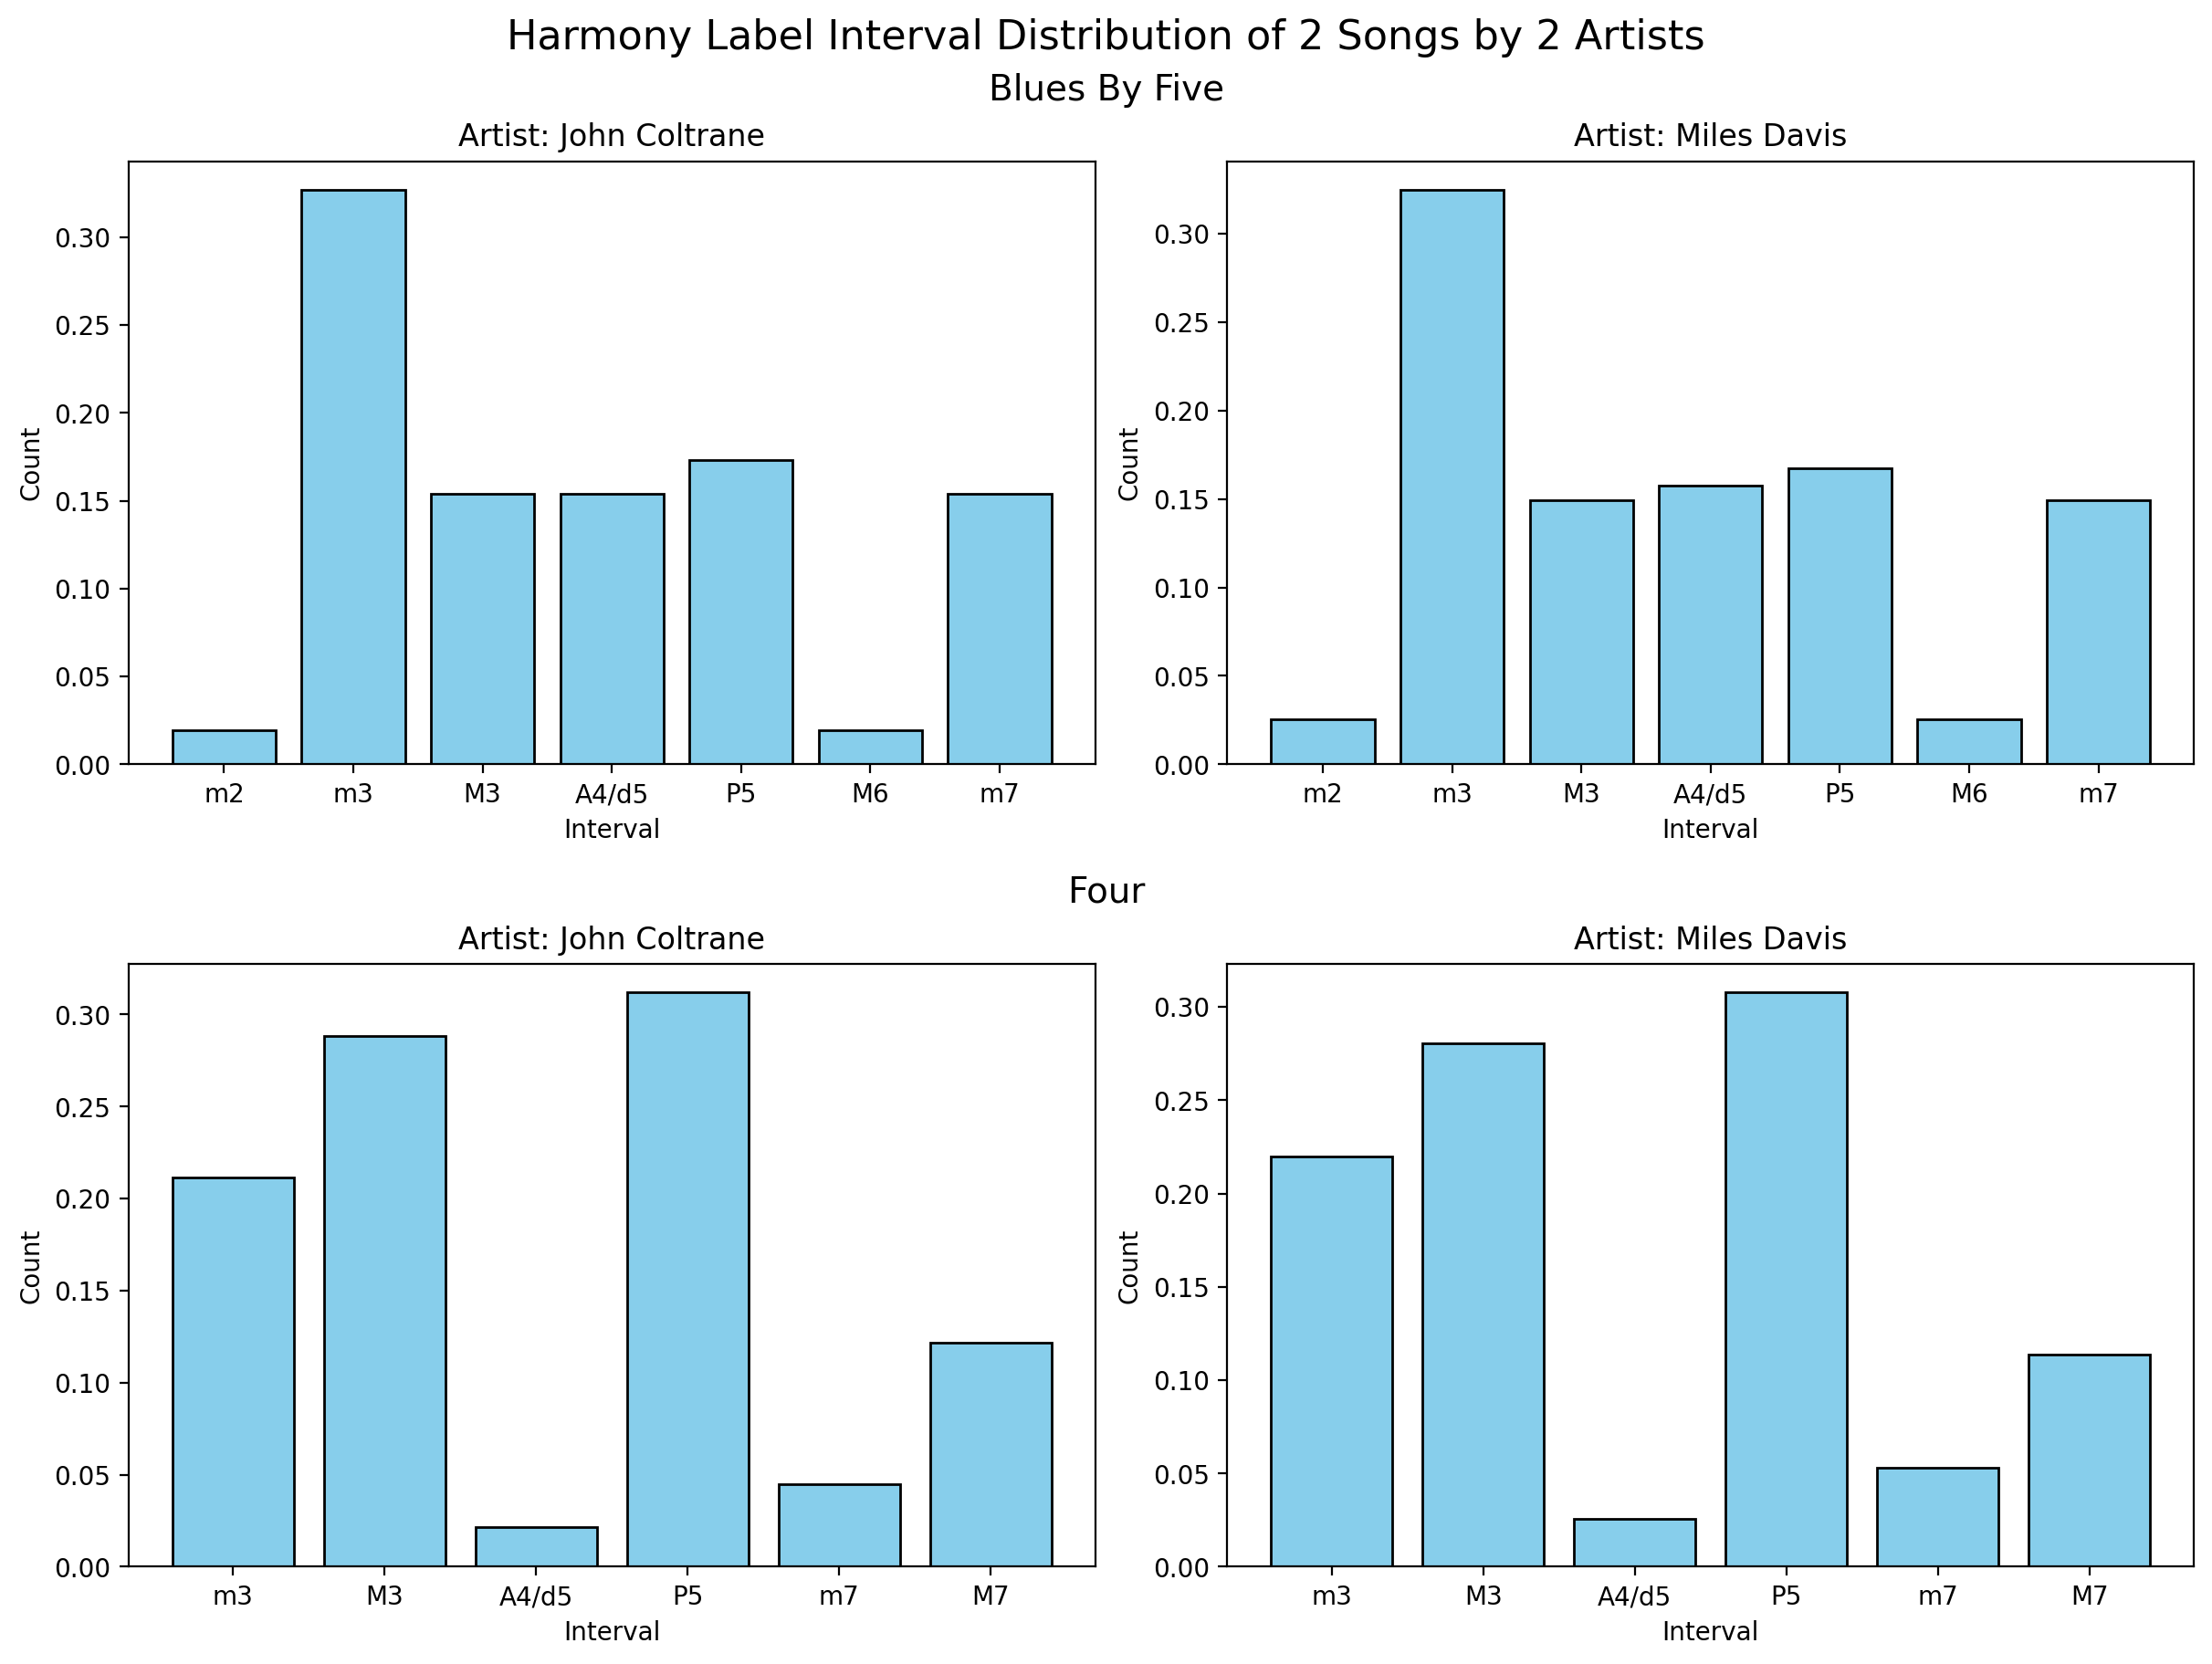

In [122]:
# --- Plot ---
fig = plt.figure(figsize=(12, 9),constrained_layout=True)
subfigs = fig.subfigures(nrows=2, ncols=1)

for i, song in enumerate(songs):
    subfig = subfigs[i]
    subfig.suptitle(f'{song}', fontsize=14)
    
    axs = subfig.subplots(nrows=1, ncols=2)
    
    row_max = 0
    for j, artist in enumerate(artists):
        ax = axs[j]
        
        # Get the pitch profile data:
        interval = data[(song, artist)]
        interval = pd.DataFrame({'interval': interval['interval'], 'duration': interval['duration_qb']})
        interval = interval.explode('interval')
        interval['interval_name'] = interval['interval'].map(pc_to_interval_name)
        interval_counts = interval.groupby(['interval', 'interval_name'])['duration'].sum().reset_index(name='weighted_count')
        count = interval_counts.sort_values('interval')

        total = count['weighted_count'].sum()

        # Add percentage column
        count['percentage'] = (count['weighted_count'] / total)
        
        # Plot histogram:
        ax.bar(count['interval_name'], count['percentage'], color='skyblue', edgecolor='black')
        
        # Set labels:
        ax.set_title(f'Artist: {artist}')
        ax.set_xlabel('Interval')
        ax.set_ylabel('Count')

# Global figure title:
fig.suptitle('Harmony Label Interval Distribution of 2 Songs by 2 Artists', fontsize=16)

plt.show()

- Next step: notes sounding at the same time (consider duration !!!)
- plot by actual interval names !
- Weigh by duration
- Normalize data
- Debug: look at two pieces in same key and two pieces in different keys to look at the interval and pitch class
- group plots by artist or key or year 